### 工作進度  
* 【置頂】**筆記內容架構**與**量化技術分析系統**相關資訊請參閱[260315筆記.ipynb](https://github.com/yilintung/StockInvestmentNotebook/blob/main/260315%E7%AD%86%E8%A8%98.ipynb)之「工作進度」。
* 到月底前技術開發工作項目：  
  - 整理「[量化技術分析系統](https://github.com/yilintung/StockInvestmentNotebook/tree/main/mysys)」程式碼。  

* 引入模組與定義公用函式  

In [1]:
import numpy as np
import mysys
import markdown
from IPython.core.display import HTML

In [2]:
def stock_analysis( analysis, stock_id, buttom_pattern = False) :
    results,images = analysis.analysis(stock_id)
    if buttom_pattern is True and '底部型態' in images :
        print('底型反轉交易策略：')
        display(images['底部型態'])
    print('解盤內容：')
    if '整體評價' in images :
        display(images['整體評價'])
    result_md   = results.to_markdown(tablefmt="grid")
    result_html = markdown.markdown(result_md, extensions=['markdown_grid_tables:GridTableExtension'])
    display(HTML(result_html))

* 更新量化技術分析資料庫  

In [ ]:
mysys.UpdateStockDatabase()

* 建立「解盤」物件    

In [3]:
analysis = mysys.StockAnalysis(debug=True)

### 大盤解盤  

* 加權指數  

> **盤後**：量化技術分析  

In [ ]:
# 盤後：加權指數解盤
stock_analysis(analysis,'TAIEX')

* 櫃買指數  

> **盤後**：量化技術分析  

In [ ]:
# 盤後：櫃買指數解盤
stock_analysis(analysis,'TPEx')

### 個股篩選  

* 選股程序    

In [ ]:
results = analysis.screener()

In [ ]:
for stock_info in results :
    print('股票代碼 ＝ {} ， 股票名稱 ＝ {} '.format(stock_info[0],stock_info[1]))

* 篩選結果  
  - 光鋐(4956)：已到壓力區  
    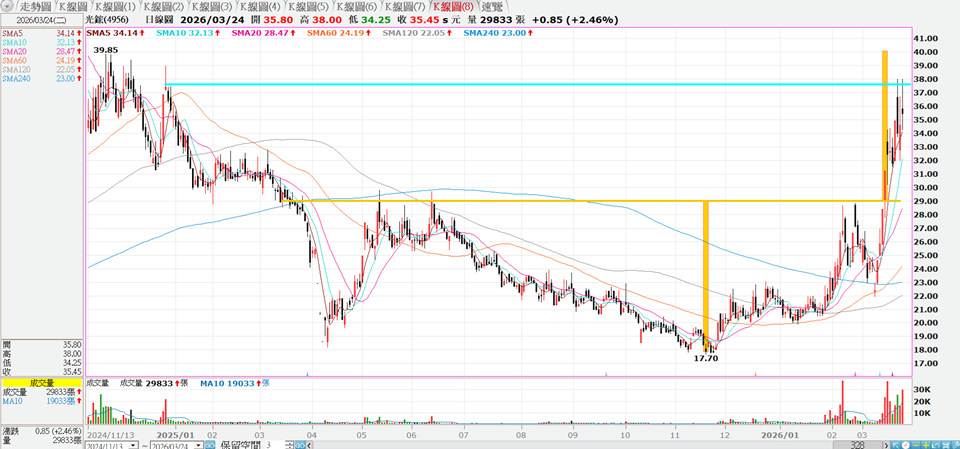
  - 中鼎(9933)：技術突破  
    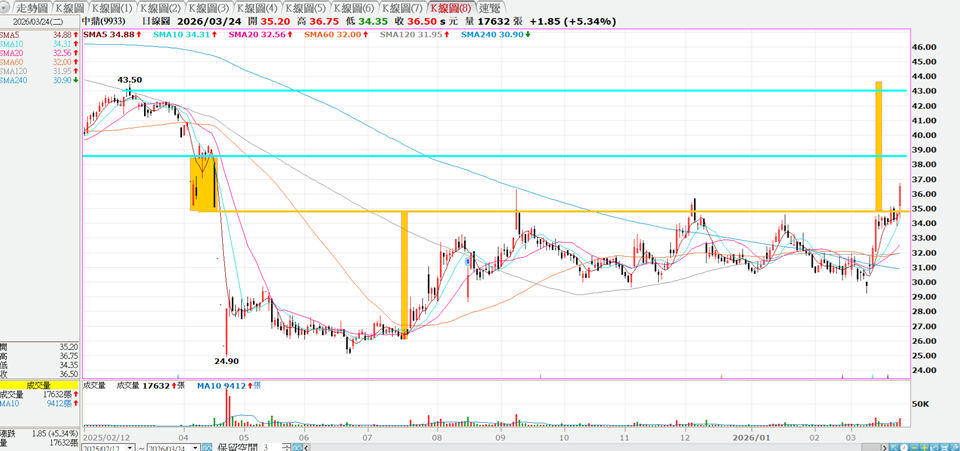

* 觀察股列表  
  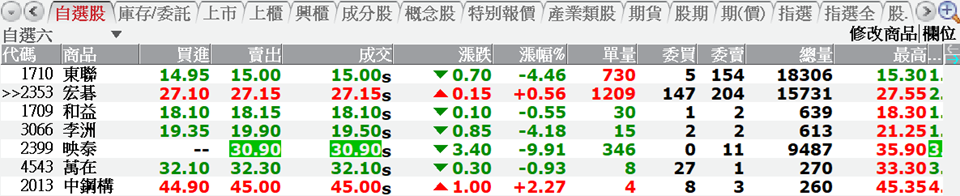  

### 個股解盤  

* 大成(1210)  
  看法：仍未有效突破底部型態。  

> **盤後**：量化技術分析   

In [ ]:
stock_analysis(analysis,'1210')

> **盤後**：底部反轉交易策略分析   

In [ ]:
def line_drawing_callback( range_prices) :
    # 設定頸線
    neckline_start_date = '2025-10-23'
    neckline_end_date   = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    neckline_price      = range_prices.loc['2025-11-10']['Open']

    # 設定底部日期與價格
    bottom_date  = '2026-03-04'
    bottom_price = range_prices.loc['2026-03-04']['Close']

    # 估算目標價
    target_price = (neckline_price - bottom_price) + neckline_price

    print('估算目標價為{:.2f}元'.format(target_price))

    seq_of_seq_of_points=[
        [(neckline_start_date,neckline_price),(neckline_end_date,neckline_price)],
        [(bottom_date,bottom_price),(bottom_date,neckline_price)],
        [(neckline_end_date,neckline_price),(neckline_end_date,target_price)]
    ]

    linewidths=[2.0,10.0,10.0]
    
    colors=['xkcd:orange yellow','xkcd:orange yellow','xkcd:orange yellow']
    
    return seq_of_seq_of_points,linewidths,colors

In [ ]:
image = mysys.DrawOnKlineChart('1210','2025-10-09','2026-03-24',line_drawing_callback)
display(image)

籌碼面：  
法人○○( )：外資○○( )、投信○○( )、自營○○( )。  
主力○○( )。  
分公司買賣家數差○○( )。  
融資○○( )、融券○○( )。  

* 宏碁(2353)   
  這檔僅作為「量化技術分析系統」解盤程序驗證之用，並不做為正式的個股解盤。已經完成確認，因此這檔追蹤至今日。    

> **盤後**：量化技術分析  
> * 型態頸線只出現一半的原因已找到：  
>   - 昨日頸線的結束位置的在底部型態的低點，並未向後延伸。  
>   - 由於原先設計是從底部型態的低點往後20根K棒確認是否突破，但可能突破的位置在第21根處。  
>   - 下圖說明所遇到的情況：  
>     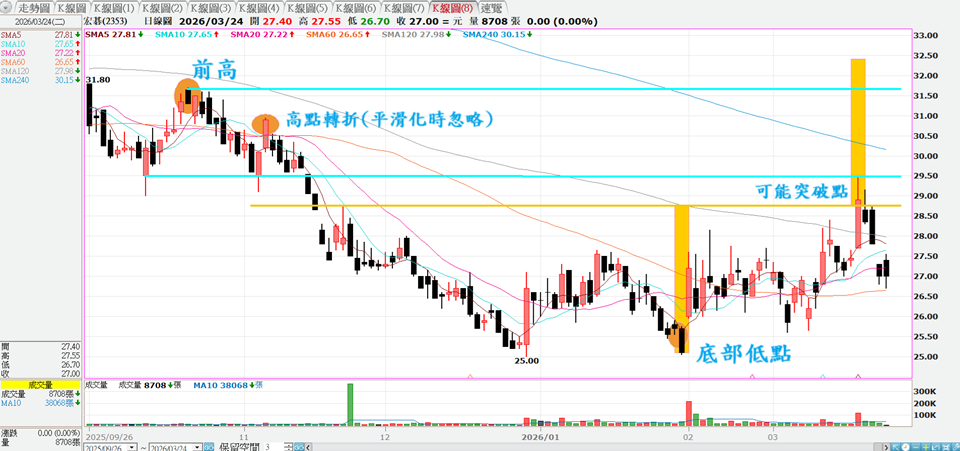  
>     轉折點資訊：  
>     {'mode': 'close', 'order': 10, 'smoothing': 3}  
>     261       2025-10-21  31.30   HI  
>     307       2025-12-26  25.20   LO  
>     320       2026-01-15  27.10   HI  
>     330       2026-01-29  25.70   LO  
>     357       2026-03-19  28.35   HI  
>   - 對策：未突破型態之頸線延伸，修改[StockAnalysis.py](https://github.com/yilintung/StockInvestmentNotebook/commit/72c93f7c33b91631d3c9bce76dcb5b7cc01f5fd7)程式對應。  

ＤＥＢＵＧ ： 日Ｋ開始日期 ＝ 2024-03-18 ，日Ｋ結束日期 ＝ 2026-03-24 ， 週Ｋ開始日期 ＝ 2024-03-18 ， 週Ｋ結束日期 ＝ 2026-03-16
ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'open_close', 'order': 5}, {'mode': 'open_close', 'order': 10}, {'mode': 'close', 'order': 10, 'smoothing': 3}]
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 0 ，結束索引 ＝ 30） 
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 0 ，結束索引 ＝ 20） 
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 0 ，結束索引 ＝ 22） 
ＤＥＢＵＧ ： 此轉折高點與底部型態之前高點間不足１５％空間，結束底部型態確認。此轉折點 ＝ 
Date     2026-03-19 00:00:00
Price                  28.35
Type                      HI
Name: 357, dtype: object
ＤＥＢＵＧ ： 底部型態開始索引 ＝ 307 （日期 ＝ 2025-12-26 ） ， 底部型態結束索引 ＝ 331 （日期 ＝ 2026-01-30 ）
ＤＥＢＵＧ ： 趨勢線開始索引 ＝ 0（價格資料開始索引 ＝ 307），趨勢線結束索引 ＝ 24（價格資料結束索引 ＝ 331）
ＤＥＢＵＧ ： 底部型態突破確認範圍 ： 331 ～ 351
ＤＥＢＵＧ ： 底部最低價格 ＝ 25.20元 ； 估算目標價 ＝ 29.87元
ＤＥＢＵＧ ： 轉折點資料確認範圍 （開始索引 ＝ 22 ，結束索引 ＝ 22） 
ＤＥＢＵＧ ： 轉折點引數列表 ＝ [{'mode': 'high_low', 'order': 5}, {'mode': 'open_close', 'order': 5}, {'mode': 'close', 'order': 10, 'smoothing': 3}, {'mode': 'close', 'order': 10, 'smoothing': 5}, {'mode': 'open_close', 'order': 10}, {'mod

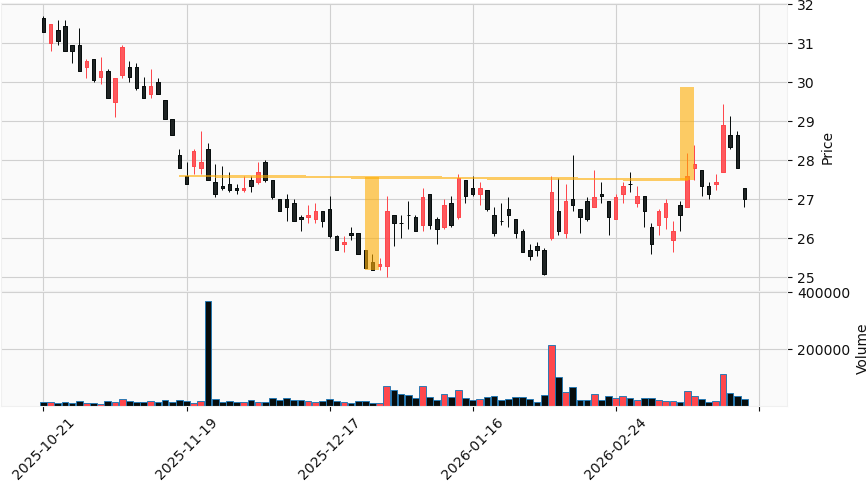

解盤內容：


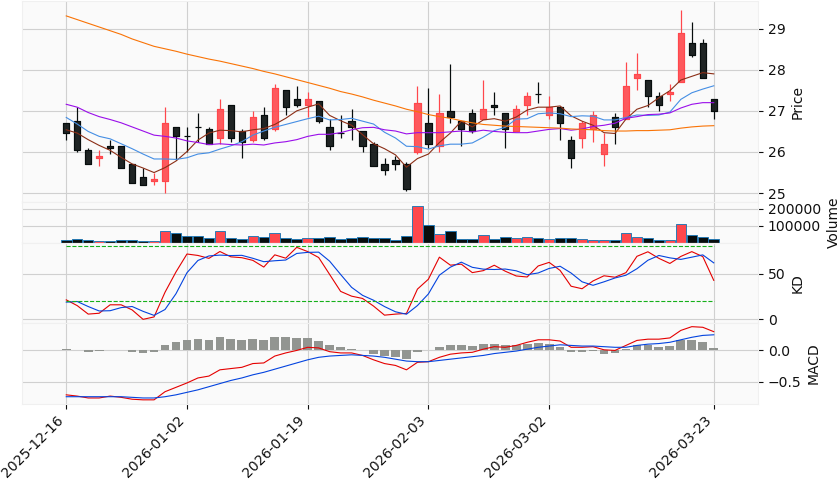

技術分析工具,解盤內容
Ｋ線／Ｋ棒,紡錘線 : 2026-03-17 十字線 : 2026-03-17 孕育線／懷抱線 : 2026-03-19
Ｋ線圖,中期為中位階 長期為低位階
成交量,價量關係：成交量小於十日均量（成交量 ＝ 25671張 ，十日均量 ＝ 38738張）
型態,尚未成形底型反轉之底部型態，型態範圍由2025-11-18開始到2026-03-11結束。
移動平均線,5日線下彎、10日線上揚，短期盤整；20日線走平、60日線上揚，中期盤整；120日線下彎、240日線下彎，長期翻空
ＫＤ指標,於2026-03-20死亡交叉。
ＭＡＣＤ指標,MACD雙線在零軸以上，中期多方
週Ｋ－週ＫＤ指標,於2026-03-16當週死亡交叉。
整體評價,價格趨勢 整體屬上漲後回檔：先急拉至接近 29.45元，隨後連續拉回至 27.0元，短線轉為偏弱整理。收盤已落在短期均線下方，但仍大致守在中期均線附近，顯示回檔尚未破壞中期結構。 價量關係 上攻時出現明顯放量，但隨後回檔量能快速縮減，屬「放量上漲、縮量回檔」的型態。惟近期回落仍以黑K為主，代表追價動能降溫，短線需觀察是否出現止跌量縮或再度放量上攻。 支撐與壓力 - 支撐：先看 26.8元（近期低點）與 27.2元（中期均線附近）作為短線防守區；若跌破，下一道支撐看 26.6元（較長天期均線附近）。 - 壓力：上方先看 27.9元（短期均線附近）與 28.0元（整數關卡）；再上去為 28.9元，強壓在 29.45元（近期高點）。 KD指標解讀 KD由中高檔明顯下彎，且K線下穿D線，顯示短線動能轉弱、回檔壓力仍在。KD目前未落入超賣區，故不宜僅以KD判定已止跌，仍需搭配價格是否守住支撐與MACD動能變化確認。 MACD指標解讀 DIF仍在MACD線之上但差距收斂，且柱狀體明顯縮短，代表多方動能快速降溫、進入高檔回檔的整理階段。若後續柱狀體轉為擴大且DIF再度上彎，才有利於恢復上攻節奏；反之若DIF跌破MACD線，回檔可能加深。 綜合評價 目前屬多方架構下的短線回檔整理：中期仍偏多，但短線因急漲後拉回，動能與指標同步轉弱。操作上以 27.2元/26.8元支撐是否守穩作為關鍵，能守住並站回 27.9元之上，才較有機會再挑戰 28.9元～29.45元壓力區。


In [4]:
stock_analysis(analysis,'2353',buttom_pattern = True)